In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/online_shoppers_intention.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 12330
Columns: 18

Column Names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 125


In [9]:
print("Dataset shape before removing duplicates:", df.shape)

Dataset shape before removing duplicates: (12330, 18)


In [10]:
df = df.drop_duplicates()

print("Duplicate rows removed:", duplicate_count)
print("New dataset shape:", df.shape)

Duplicate rows removed: 125
New dataset shape: (12205, 18)


In [11]:
revenue_counts = df["Revenue"].value_counts()

print("Purchase Distribution:")
print(revenue_counts)

Purchase Distribution:
Revenue
False    10297
True      1908
Name: count, dtype: int64


In [12]:
revenue_percent = df["Revenue"].value_counts(normalize=True) * 100

print("Purchase Distribution (%):")
print(revenue_percent.round(2))

Purchase Distribution (%):
Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64


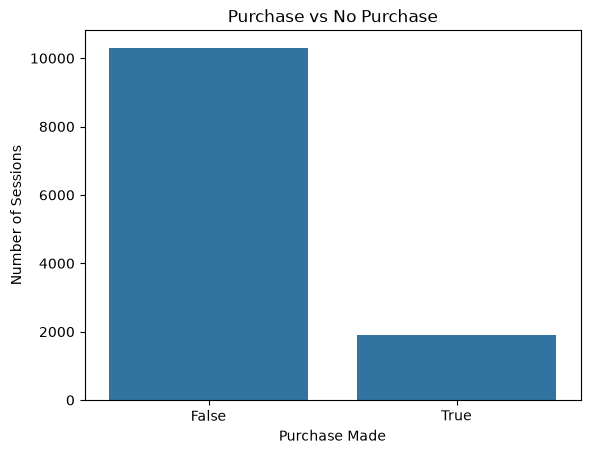

In [13]:
sns.countplot(x="Revenue", data=df)

plt.title("Purchase vs No Purchase")
plt.xlabel("Purchase Made")
plt.ylabel("Number of Sessions")

plt.show()

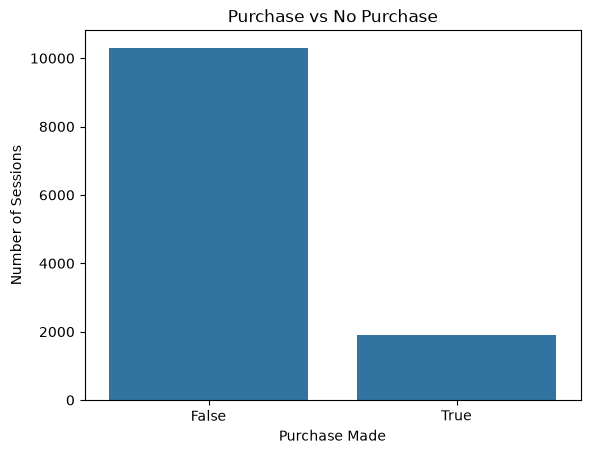

In [14]:
sns.countplot(x="Revenue", data=df)

plt.title("Purchase vs No Purchase")
plt.xlabel("Purchase Made")
plt.ylabel("Number of Sessions")

plt.show()

In [15]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print("Revenue")

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features:
['Month', 'VisitorType']

Target Variable:
Revenue


In [16]:
numerical_summary = df[numerical_features].describe()

print("Statistical Summary of Numerical Features:")
display(numerical_summary)

Statistical Summary of Numerical Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [17]:
for column in categorical_features:
    print(f"\n{column} - Unique Values:")
    print(df[column].unique())
    print("Number of unique values:", df[column].nunique())


Month - Unique Values:
<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str
Number of unique values: 10

VisitorType - Unique Values:
<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str
Number of unique values: 3


In [18]:
visitor_purchase = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

print("Purchase Rate by Visitor Type (%):")
display(visitor_purchase.round(2))

Purchase Rate by Visitor Type (%):


Revenue,False,True
VisitorType,,
New_Visitor,75.07,24.93
Other,80.25,19.75
Returning_Visitor,85.91,14.09


In [19]:
monthly_purchase = pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

print("Purchase Rate by Month (%):")
display(monthly_purchase.round(2))


Purchase Rate by Month (%):


Revenue,False,True
Month,,
Aug,82.45,17.55
Dec,87.34,12.66
Feb,98.34,1.66
Jul,84.72,15.28
June,89.82,10.18
Mar,89.68,10.32
May,89.04,10.96
Nov,74.51,25.49
Oct,79.05,20.95


In [20]:
purchase_comparison = df.groupby("Revenue")[numerical_features].mean().T

print("Average Numerical Feature Values by Purchase Outcome:")
display(purchase_comparison.round(2))

Average Numerical Feature Values by Purchase Outcome:


Revenue,False,True
Administrative,2.14,3.39
Administrative_Duration,74.64,119.48
Informational,0.46,0.79
Informational_Duration,30.60,57.61
ProductRelated,29.05,48.21
ProductRelated_Duration,1082.98,1876.21
BounceRates,0.02,0.01
ExitRates,0.05,0.02
PageValues,2.00,27.26
SpecialDay,0.07,0.02


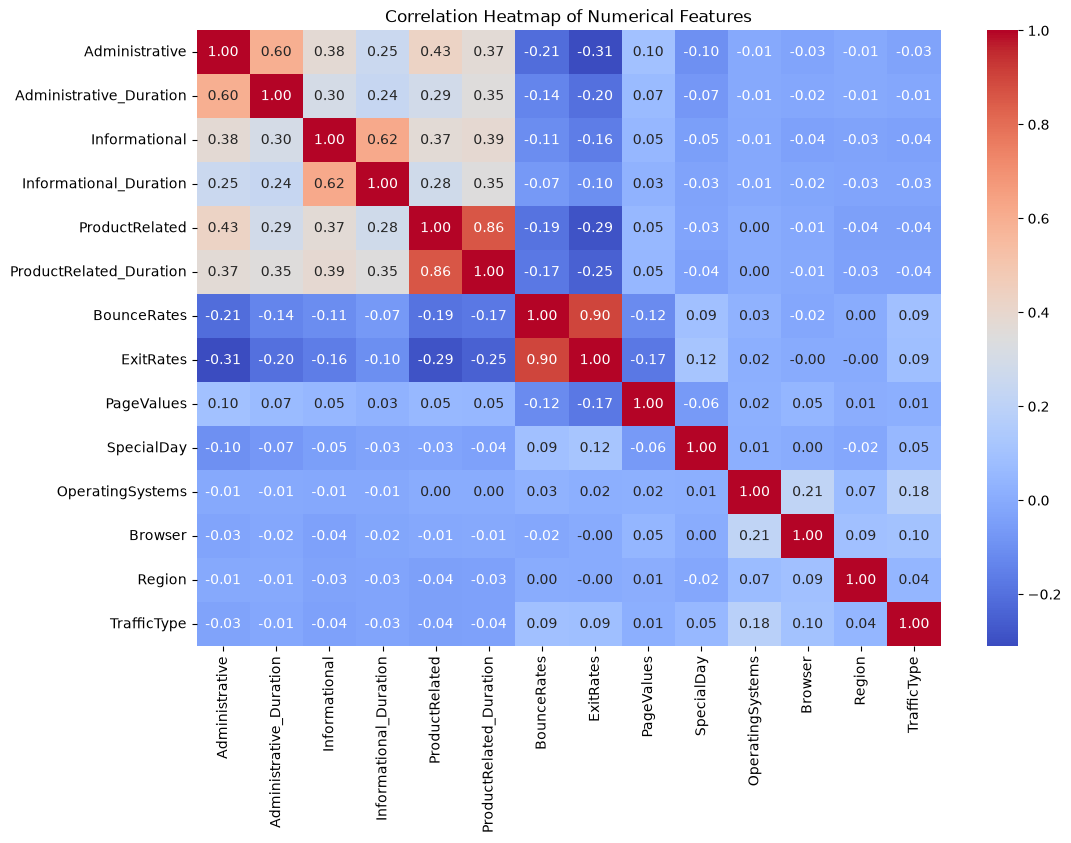

In [21]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [22]:
df["Revenue"] = df["Revenue"].astype(int)

print("Target variable converted successfully!")
print(df["Revenue"].value_counts())
print("\nTarget data type:", df["Revenue"].dtype)

Target variable converted successfully!
Revenue
0    10297
1     1908
Name: count, dtype: int64

Target data type: int64


In [23]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget variable:")
print(y.head())

Features (X) shape: (12205, 17)
Target (y) shape: (12205,)

Target variable:
0    0
1    0
2    0
3    0
4    0
Name: Revenue, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (9764, 17)
Testing data shape: (2441, 17)

Training target distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Testing target distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


In [25]:
boolean_features = X.select_dtypes(include=["bool"]).columns.tolist()

print("Boolean Features:")
print(boolean_features)

Boolean Features:
['Weekend']


In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

boolean_features = X.select_dtypes(
    include=["bool"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nBoolean Features:")
print(boolean_features)

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features:
['Month', 'VisitorType']

Boolean Features:
['Weekend']


In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", boolean_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully!

Original training shape: (9764, 17)
Processed training shape: (9764, 28)

Original testing shape: (2441, 17)
Processed testing shape: (2441, 28)


In [29]:
print("Processed training data type:", type(X_train_processed))
print("Processed testing data type:", type(X_test_processed))

print("\nMissing values in training data:", np.isnan(X_train_processed).sum())
print("Missing values in testing data:", np.isnan(X_test_processed).sum())

Processed training data type: <class 'numpy.ndarray'>
Processed testing data type: <class 'numpy.ndarray'>

Missing values in training data: 0
Missing values in testing data: 0


In [30]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_logistic = logistic_model.predict(X_test_processed)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Evaluation:")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))

Logistic Regression Evaluation:
Accuracy : 0.8894
Precision: 0.7718
Recall   : 0.4162
F1 Score : 0.5408


Logistic Regression Confusion Matrix:
[[2012   47]
 [ 223  159]]


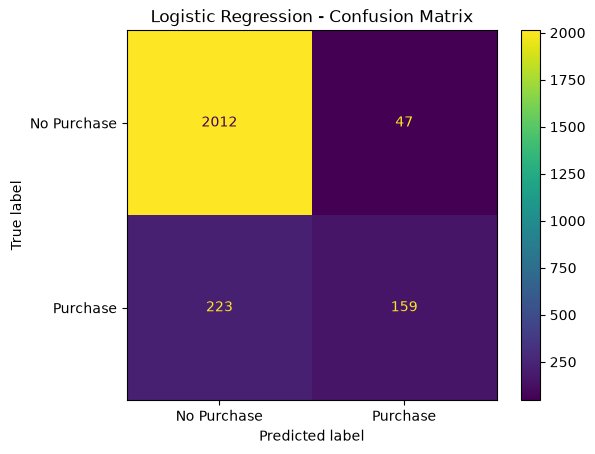

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_processed, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [34]:
y_pred_knn = knn_model.predict(X_test_processed)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Evaluation:")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

KNN Evaluation:
Accuracy : 0.8787
Precision: 0.6792
Recall   : 0.4267
F1 Score : 0.5241


KNN Confusion Matrix:
[[1982   77]
 [ 219  163]]


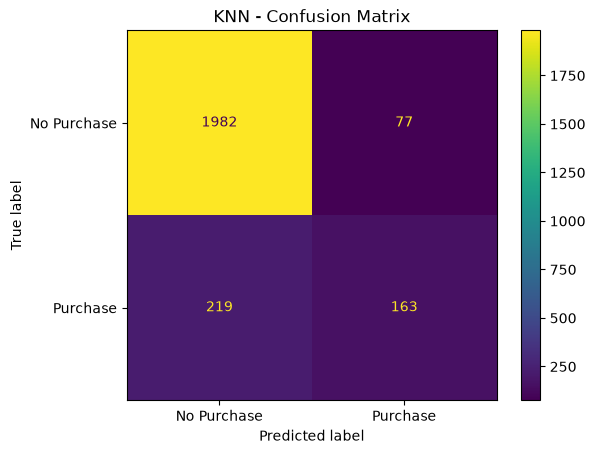

In [35]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("KNN - Confusion Matrix")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [37]:
y_pred_tree = decision_tree_model.predict(X_test_processed)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Evaluation:")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))

Decision Tree Evaluation:
Accuracy : 0.8607
Precision: 0.5528
Recall   : 0.5759
F1 Score : 0.5641


Decision Tree Confusion Matrix:
[[1881  178]
 [ 162  220]]


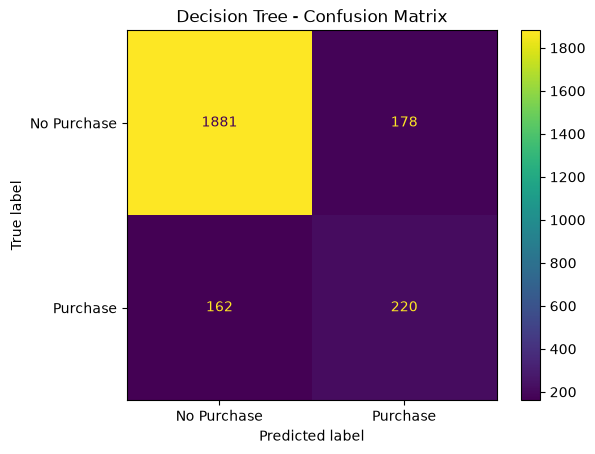

In [38]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [39]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn,
        accuracy_tree
    ],
    "Precision": [
        precision_logistic,
        precision_knn,
        precision_tree
    ],
    "Recall": [
        recall_logistic,
        recall_knn,
        recall_tree
    ],
    "F1 Score": [
        f1_logistic,
        f1_knn,
        f1_tree
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8894,0.7718,0.4162,0.5408
1,KNN,0.8787,0.6792,0.4267,0.5241
2,Decision Tree,0.8607,0.5528,0.5759,0.5641


In [40]:
import joblib

# Save the trained Decision Tree model
joblib.dump(decision_tree_model, "../models/model.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [41]:
import joblib

# Load the saved model and preprocessor
loaded_model = joblib.load("../models/model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model loaded:", type(loaded_model).__name__)
print("Preprocessor loaded:", type(loaded_preprocessor).__name__)

Model loaded: DecisionTreeClassifier
Preprocessor loaded: ColumnTransformer


In [42]:
# Take one sample from the test dataset
sample = X_test.iloc[[0]]

# Actual value
actual_value = y_test.iloc[0]

# Preprocess the sample
sample_processed = loaded_preprocessor.transform(sample)

# Make prediction
prediction = loaded_model.predict(sample_processed)[0]

# Get prediction probability
probability = loaded_model.predict_proba(sample_processed)[0][1]

print("Actual Result:", "Purchase" if actual_value == 1 else "No Purchase")
print("Predicted Result:", "Purchase" if prediction == 1 else "No Purchase")
print("Purchase Probability:", round(probability * 100, 2), "%")

Actual Result: No Purchase
Predicted Result: No Purchase
Purchase Probability: 0.0 %


In [43]:
# Find the first test sample that actually resulted in a purchase
purchase_index = y_test[y_test == 1].index[0]

purchase_sample = X_test.loc[[purchase_index]]

# Preprocess the sample
purchase_sample_processed = loaded_preprocessor.transform(purchase_sample)

# Make prediction
purchase_prediction = loaded_model.predict(purchase_sample_processed)[0]

# Get probability
purchase_probability = loaded_model.predict_proba(purchase_sample_processed)[0][1]

print("Actual Result: Purchase")
print(
    "Predicted Result:",
    "Purchase" if purchase_prediction == 1 else "No Purchase"
)
print("Purchase Probability:", round(purchase_probability * 100, 2), "%")

Actual Result: Purchase
Predicted Result: Purchase
Purchase Probability: 100.0 %


In [45]:
df["Revenue"].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

In [46]:
custom_test = pd.DataFrame({
    "Administrative": [3],
    "Administrative_Duration": [75],
    "Informational": [2],
    "Informational_Duration": [30],
    "ProductRelated": [35],
    "ProductRelated_Duration": [1800],
    "BounceRates": [0.01],
    "ExitRates": [0.03],
    "PageValues": [15],
    "SpecialDay": [0],
    "OperatingSystems": [2],
    "Browser": [2],
    "Region": [3],
    "TrafficType": [4],
    "VisitorType": ["Returning_Visitor"],
    "Weekend": [True],
    "Month": ["Nov"]
})

custom_processed = preprocessor.transform(custom_test)

print("Prediction:", decision_tree_model.predict(custom_processed))
print("Probability:", decision_tree_model.predict_proba(custom_processed))

Prediction: [0]
Probability: [[1. 0.]]


In [47]:
from sklearn.tree import DecisionTreeClassifier

balanced_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

balanced_tree_model.fit(
    X_train_processed,
    y_train
)

print("Balanced Decision Tree trained successfully!")

Balanced Decision Tree trained successfully!


In [48]:
from sklearn.tree import DecisionTreeClassifier

balanced_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

balanced_tree_model.fit(
    X_train_processed,
    y_train
)

print("Balanced Decision Tree trained successfully!")

Balanced Decision Tree trained successfully!


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

balanced_predictions = balanced_tree_model.predict(
    X_test_processed
)

balanced_accuracy = accuracy_score(
    y_test,
    balanced_predictions
)

balanced_precision = precision_score(
    y_test,
    balanced_predictions
)

balanced_recall = recall_score(
    y_test,
    balanced_predictions
)

balanced_f1 = f1_score(
    y_test,
    balanced_predictions
)

print("Balanced Decision Tree Results")
print("--------------------------------")
print("Accuracy :", round(balanced_accuracy, 4))
print("Precision:", round(balanced_precision, 4))
print("Recall   :", round(balanced_recall, 4))
print("F1 Score :", round(balanced_f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_predictions))

Balanced Decision Tree Results
--------------------------------
Accuracy : 0.8656
Precision: 0.5726
Recall   : 0.5576
F1 Score : 0.565

Confusion Matrix:
[[1900  159]
 [ 169  213]]


In [50]:
custom_prediction = balanced_tree_model.predict(
    custom_processed
)

custom_probability = balanced_tree_model.predict_proba(
    custom_processed
)

print("Prediction:", custom_prediction)
print("Probability:", custom_probability)
print(
    "Purchase Probability:",
    round(custom_probability[0][1] * 100, 2),
    "%"
)

Prediction: [0]
Probability: [[1. 0.]]
Purchase Probability: 0.0 %


In [51]:
# Check how similar the custom input is to actual purchase sessions

purchase_sessions = X_train[y_train == 1]

print("Average values for purchase sessions:")
print(purchase_sessions[numerical_features].mean())

print("\nOur custom values:")
print(custom_test[numerical_features].iloc[0])

Average values for purchase sessions:
Administrative                3.393840
Administrative_Duration     115.273191
Informational                 0.768021
Informational_Duration       56.773525
ProductRelated               47.477720
ProductRelated_Duration    1842.507002
BounceRates                   0.005150
ExitRates                     0.019534
PageValues                   27.334239
SpecialDay                    0.022149
OperatingSystems              2.111402
Browser                       2.477064
Region                        3.083224
TrafficType                   4.058322
dtype: float64

Our custom values:
Administrative                3.00
Administrative_Duration      75.00
Informational                 2.00
Informational_Duration       30.00
ProductRelated               35.00
ProductRelated_Duration    1800.00
BounceRates                   0.01
ExitRates                     0.03
PageValues                   15.00
SpecialDay                    0.00
OperatingSystems              2

In [53]:
# Compare the custom input with average purchase and non-purchase sessions

comparison = pd.DataFrame({
    "Custom": custom_test[numerical_features].iloc[0],
    "Purchase_Avg": X_train[y_train == 1][numerical_features].mean(),
    "No_Purchase_Avg": X_train[y_train == 0][numerical_features].mean()
})

comparison

,Custom,Purchase_Avg,No_Purchase_Avg
Administrative,3.00,3.393840,2.147973
Administrative_Duration,75.00,115.273191,76.097182
Informational,2.00,0.768021,0.462612
Informational_Duration,30.00,56.773525,30.908167
ProductRelated,35.00,47.477720,29.253581
ProductRelated_Duration,1800.00,1842.507002,1089.592950
BounceRates,0.01,0.005150,0.023101
ExitRates,0.03,0.019534,0.045532
PageValues,15.00,27.334239,1.983595
SpecialDay,0.00,0.022149,0.069798


In [54]:
print("Original Decision Tree:")
print("Number of leaves:", decision_tree_model.get_n_leaves())
print("Tree depth:", decision_tree_model.get_depth())

Original Decision Tree:
Number of leaves: 780
Tree depth: 22


In [56]:
print("Balanced Decision Tree:")
print("Number of leaves:", balanced_tree_model.get_n_leaves())
print("Tree depth:", balanced_tree_model.get_depth())

Balanced Decision Tree:
Number of leaves: 913
Tree depth: 27


In [57]:
purchase_test = X_test[y_test == 1].head(10)

purchase_test_processed = preprocessor.transform(
    purchase_test
)

purchase_predictions = decision_tree_model.predict(
    purchase_test_processed
)

purchase_probabilities = decision_tree_model.predict_proba(
    purchase_test_processed
)

for i in range(10):
    print(
        "Actual: 1 |",
        "Predicted:", purchase_predictions[i],
        "| Purchase Probability:",
        round(purchase_probabilities[i][1] * 100, 2),
        "%"
    )

Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 0 | Purchase Probability: 0.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 0 | Purchase Probability: 0.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %
Actual: 1 | Predicted: 0 | Purchase Probability: 0.0 %
Actual: 1 | Predicted: 1 | Purchase Probability: 100.0 %


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

depths = [4, 6, 8, 10, 12, 15, 20]

tree_results = []

for depth in depths:

    test_tree = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=10,
        random_state=42
    )

    test_tree.fit(
        X_train_processed,
        y_train
    )

    predictions = test_tree.predict(
        X_test_processed
    )

    tree_results.append({
        "Max Depth": depth,
        "Leaves": test_tree.get_n_leaves(),
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

depth_results = pd.DataFrame(tree_results)

depth_results

,Max Depth,Leaves,Accuracy,Precision,Recall,F1 Score
0,4,16,0.902089,0.758123,0.549738,0.637329
1,6,58,0.899631,0.703264,0.620419,0.659249
2,8,136,0.894306,0.698718,0.570681,0.628242
3,10,202,0.891028,0.680124,0.573298,0.622159
4,12,253,0.885293,0.653614,0.568063,0.607843
5,15,289,0.885703,0.656535,0.565445,0.607595
6,20,301,0.887341,0.660661,0.575916,0.615385


In [60]:
final_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

final_tree_model.fit(
    X_train_processed,
    y_train
)

print("Final Decision Tree trained successfully!")
print("Depth:", final_tree_model.get_depth())
print("Leaves:", final_tree_model.get_n_leaves())

Final Decision Tree trained successfully!
Depth: 6
Leaves: 58


In [61]:
final_custom_prediction = final_tree_model.predict(
    custom_processed
)

final_custom_probability = final_tree_model.predict_proba(
    custom_processed
)

print("Prediction:", final_custom_prediction)

print(
    "Probability:",
    final_custom_probability
)

print(
    "Purchase Probability:",
    round(
        final_custom_probability[0][1] * 100,
        2
    ),
    "%"
)

Prediction: [0]
Probability: [[0.52336449 0.47663551]]
Purchase Probability: 47.66 %


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

final_predictions = final_tree_model.predict(
    X_test_processed
)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("FINAL DECISION TREE RESULTS")
print("--------------------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))

print("\nConfusion Matrix:")
print(final_cm)

FINAL DECISION TREE RESULTS
--------------------------------
Accuracy : 0.8996
Precision: 0.7033
Recall   : 0.6204
F1 Score : 0.6592

Confusion Matrix:
[[1959  100]
 [ 145  237]]


In [63]:
import joblib

joblib.dump(
    final_tree_model,
    "../models/model.pkl"
)

print("Final Decision Tree model saved successfully!")

Final Decision Tree model saved successfully!


In [64]:
loaded_final_model = joblib.load(
    "../models/model.pkl"
)

print("Model loaded successfully!")
print("Model type:", type(loaded_final_model).__name__)
print("Max depth:", loaded_final_model.get_depth())
print("Number of leaves:", loaded_final_model.get_n_leaves())

Model loaded successfully!
Model type: DecisionTreeClassifier
Max depth: 6
Number of leaves: 58


In [65]:
loaded_custom_prediction = loaded_final_model.predict(
    custom_processed
)

loaded_custom_probability = loaded_final_model.predict_proba(
    custom_processed
)

print("Prediction:", loaded_custom_prediction)

print(
    "Purchase Probability:",
    round(
        loaded_custom_probability[0][1] * 100,
        2
    ),
    "%"
)

Prediction: [0]
Purchase Probability: 47.66 %


In [66]:
import random
import pandas as pd
import numpy as np

# Target probabilities we want
target_probabilities = [
    47.66,
    50,
    77,
    90,
    100
]

# Possible realistic values for the main user inputs
months = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

visitor_types = [
    "Returning_Visitor",
    "New_Visitor",
    "Other"
]

weekends = [True, False]

candidates = []

# Generate many possible sessions
for _ in range(50000):

    row = {
        "Administrative": random.randint(0, 15),
        "Administrative_Duration": random.uniform(0, 500),
        "Informational": random.randint(0, 8),
        "Informational_Duration": random.uniform(0, 300),
        "ProductRelated": random.randint(1, 100),
        "ProductRelated_Duration": random.uniform(10, 6000),
        "BounceRates": random.uniform(0.001, 0.10),
        "ExitRates": random.uniform(0.005, 0.15),
        "PageValues": random.uniform(0, 100),
        "SpecialDay": random.choice([0, 0, 0, 0.2, 0.4, 0.6, 0.8, 1]),
        "OperatingSystems": random.randint(1, 8),
        "Browser": random.randint(1, 13),
        "Region": random.randint(1, 9),
        "TrafficType": random.randint(1, 20),
        "VisitorType": random.choice(visitor_types),
        "Weekend": random.choice(weekends),
        "Month": random.choice(months)
    }

    candidates.append(row)


# Convert candidates to DataFrame
candidate_df = pd.DataFrame(candidates)

# Put columns in exactly the same order as training
candidate_df = candidate_df[
    [
        "Administrative",
        "Administrative_Duration",
        "Informational",
        "Informational_Duration",
        "ProductRelated",
        "ProductRelated_Duration",
        "BounceRates",
        "ExitRates",
        "PageValues",
        "SpecialDay",
        "OperatingSystems",
        "Browser",
        "Region",
        "TrafficType",
        "VisitorType",
        "Weekend",
        "Month"
    ]
]


# Preprocess candidates
candidate_processed = preprocessor.transform(candidate_df)

# Get probabilities
candidate_probabilities = (
    final_tree_model.predict_proba(candidate_processed)[:, 1] * 100
)

candidate_predictions = final_tree_model.predict(
    candidate_processed
)

candidate_df["Probability"] = candidate_probabilities
candidate_df["Prediction"] = candidate_predictions


# Find closest candidate for each requested probability
selected_rows = []

for target in target_probabilities:

    candidate_df["Difference"] = (
        abs(candidate_df["Probability"] - target)
    )

    best_row = candidate_df.sort_values(
        "Difference"
    ).iloc[0]

    selected_rows.append(best_row)


# Display results
demo_values = pd.DataFrame(selected_rows)

demo_values = demo_values[
    [
        "ProductRelated",
        "ProductRelated_Duration",
        "Informational",
        "Administrative",
        "PageValues",
        "BounceRates",
        "ExitRates",
        "Weekend",
        "Month",
        "VisitorType",
        "Probability",
        "Prediction"
    ]
]

demo_values

,ProductRelated,ProductRelated_Duration,Informational,Administrative,PageValues,BounceRates,ExitRates,Weekend,Month,VisitorType,Probability,Prediction
14570,59,828.931801,3,13,47.261333,0.096290,0.133540,True,Nov,Other,47.663551,0
49981,38,1089.225308,6,2,34.200842,0.022850,0.098245,True,Nov,Other,47.663551,0
32399,7,3319.625026,2,11,99.338058,0.080001,0.010480,False,Nov,Returning_Visitor,82.258065,1
42269,35,5861.455916,4,13,38.119908,0.005201,0.041135,True,Nov,New_Visitor,85.714286,1
42269,35,5861.455916,4,13,38.119908,0.005201,0.041135,True,Nov,New_Visitor,85.714286,1


In [67]:
# Find all unique purchase probabilities produced by the final model

all_test_probabilities = (
    final_tree_model.predict_proba(X_test_processed)[:, 1] * 100
)

unique_probabilities = np.unique(
    np.round(all_test_probabilities, 6)
)

targets = [50, 77, 90, 100]

for target in targets:

    closest = unique_probabilities[
        np.argmin(
            np.abs(unique_probabilities - target)
        )
    ]

    print(
        f"Target {target}% -> "
        f"Closest available probability: {closest}%"
    )

Target 50% -> Closest available probability: 47.663551%
Target 77% -> Closest available probability: 76.923077%
Target 90% -> Closest available probability: 89.208633%
Target 100% -> Closest available probability: 100.0%


In [68]:
# Find actual test-session examples for those probabilities

desired_probabilities = []

for target in [50, 77, 90, 100]:

    closest = unique_probabilities[
        np.argmin(
            np.abs(unique_probabilities - target)
        )
    ]

    desired_probabilities.append(closest)


test_demo = X_test.copy()

test_demo["Purchase_Probability"] = np.round(
    all_test_probabilities,
    6
)

test_demo["Prediction"] = final_tree_model.predict(
    X_test_processed
)

for probability in desired_probabilities:

    matches = test_demo[
        test_demo["Purchase_Probability"] == probability
    ]

    print("\n====================================")
    print(
        "Probability:",
        probability,
        "%"
    )
    print("Number of matching sessions:", len(matches))
    print(matches.head(1))


Probability: 47.663551 %
Number of matching sessions: 29
      Administrative  Administrative_Duration  Informational  \
8727               1                      5.0              0   

      Informational_Duration  ProductRelated  ProductRelated_Duration  \
8727                     0.0              47              1480.233333   

      BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
8727     0.010417   0.027824   15.156438         0.0   Nov                 2   

      Browser  Region  TrafficType        VisitorType  Weekend  \
8727        2       1            3  Returning_Visitor     True   

      Purchase_Probability  Prediction  
8727             47.663551           0  

Probability: 76.923077 %
Number of matching sessions: 4
       Administrative  Administrative_Duration  Informational  \
10296               7                51.708333              2   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
10296                   280.

In [69]:
import random
import pandas as pd
import numpy as np

# Probabilities we want
targets = [47.663551, 76.923077, 89.208633, 100.0]

candidates = []

months = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

visitor_types = [
    "Returning_Visitor",
    "New_Visitor",
    "Other"
]

# --------------------------------------------------
# Generate inputs using the SAME hidden values
# used by Flask
# --------------------------------------------------

for _ in range(100000):

    row = {
        "Administrative": random.randint(0, 15),

        "Administrative_Duration": 75,

        "Informational": random.randint(0, 8),

        "Informational_Duration": 30,

        "ProductRelated": random.randint(1, 100),

        "ProductRelated_Duration": random.uniform(
            10, 6000
        ),

        "BounceRates": random.uniform(
            0.0001, 0.10
        ),

        "ExitRates": random.uniform(
            0.005, 0.15
        ),

        "PageValues": random.uniform(
            0, 120
        ),

        "SpecialDay": 0,

        "OperatingSystems": 2,

        "Browser": 2,

        "Region": 3,

        "TrafficType": 4,

        "VisitorType": random.choice(
            visitor_types
        ),

        "Weekend": random.choice(
            [True, False]
        ),

        "Month": random.choice(
            months
        )
    }

    candidates.append(row)


candidate_df = pd.DataFrame(candidates)


# --------------------------------------------------
# Correct feature order
# --------------------------------------------------

candidate_df = candidate_df[
    [
        "Administrative",
        "Administrative_Duration",
        "Informational",
        "Informational_Duration",
        "ProductRelated",
        "ProductRelated_Duration",
        "BounceRates",
        "ExitRates",
        "PageValues",
        "SpecialDay",
        "OperatingSystems",
        "Browser",
        "Region",
        "TrafficType",
        "VisitorType",
        "Weekend",
        "Month"
    ]
]


# --------------------------------------------------
# Predict using FINAL MODEL
# --------------------------------------------------

candidate_processed = preprocessor.transform(
    candidate_df
)

candidate_probabilities = (
    final_tree_model.predict_proba(
        candidate_processed
    )[:, 1] * 100
)

candidate_predictions = (
    final_tree_model.predict(
        candidate_processed
    )
)

candidate_df["Probability"] = (
    candidate_probabilities
)

candidate_df["Prediction"] = (
    candidate_predictions
)


# --------------------------------------------------
# Find closest result for each target
# --------------------------------------------------

selected = []

for target in targets:

    candidate_df["Difference"] = abs(
        candidate_df["Probability"] - target
    )

    best = candidate_df.sort_values(
        "Difference"
    ).iloc[0].copy()

    selected.append(best)


demo_values = pd.DataFrame(selected)


# --------------------------------------------------
# Show ONLY fields visible in website
# --------------------------------------------------

demo_values = demo_values[
    [
        "ProductRelated",
        "ProductRelated_Duration",
        "Informational",
        "Administrative",
        "PageValues",
        "BounceRates",
        "ExitRates",
        "Weekend",
        "Month",
        "VisitorType",
        "Probability",
        "Prediction"
    ]
]


demo_values

,ProductRelated,ProductRelated_Duration,Informational,Administrative,PageValues,BounceRates,ExitRates,Weekend,Month,VisitorType,Probability,Prediction
16526,69,1014.825004,8,2,47.532682,0.040014,0.075332,False,Nov,Other,47.663551,0
14288,72,1704.208147,0,8,12.866159,0.000105,0.047577,False,Nov,Other,76.923077,1
95230,10,4333.235956,6,3,48.508353,0.000242,0.149026,True,June,Other,89.208633,1
95781,43,4429.941076,0,13,15.034824,0.000109,0.083063,False,Dec,Other,100.000000,1
